# Malaysia Fish Landings & Economic Indicators
## Phase 4 — Cross-Correlation Analysis (CCF) + EDA

**Purpose:** Before running formal Granger causality tests, we first examine  
*temporal lead-lag relationships* visually using Cross-Correlation Functions (CCF).

CCF answers: **"Does fish landings at time t predict economic variable Y at time t+k?"**  
(and vice versa — does Y lead landings?)

This is exploratory — it motivates the VAR lag structure and Granger test directions.  
CCF plots are standard in time-series papers (Stergiou & Christou 1997; Compaire et al. 2024).

**Variables used:** First-differenced log series (Δln) — consistent with Phase 3 decisions.  
**Input:** `master_dataset_analysis.csv`

---
## Setup, Load & Prepare

In [1]:
# Cell P4.1 — Setup, load, and prepare all series in one block
!pip install pandas numpy matplotlib scipy statsmodels -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'axes.labelsize': 9,
    'axes.grid': True, 'grid.alpha': 0.3,
})
PALETTE  = ['#2196F3','#E91E63','#4CAF50','#FF9800','#9C27B0']
OUT      = "/content/drive/MyDrive/FishStatPj/Paper3EcoandFish/outputs/"
BASE     = "/content/drive/MyDrive/FishStatPj/Paper3EcoandFish/outputs/"

df = pd.read_csv(BASE + "master_dataset_analysis.csv")
df['quarter'] = pd.PeriodIndex(df['quarter_str'], freq='Q')
df = df.sort_values('quarter').reset_index(drop=True)

# Working series — first-differenced log (Phase 3 decision)
# Drop first row (NaN from differencing)
ts = df[['dln_landings','dln_gdp_fishing','dln_cpi_food','dln_food_exports']].dropna().copy()
ts.index = df['quarter'].iloc[1:].values  # attach quarter labels

LABELS = {
    'dln_landings':     'Δln(Fish Landings)',
    'dln_gdp_fishing':  'Δln(Fishing GDP)',
    'dln_cpi_food':     'Δln(Food CPI)',
    'dln_food_exports': 'Δln(Food Exports)',
}
print(f"Working series: {ts.shape[0]} obs x {ts.shape[1]} variables")
print(f"Period: {ts.index[0]} to {ts.index[-1]}")
print(f"Variables: {list(ts.columns)}")

Mounted at /content/drive
Working series: 23 obs x 4 variables
Period: 2018Q2 to 2023Q4
Variables: ['dln_landings', 'dln_gdp_fishing', 'dln_cpi_food', 'dln_food_exports']


---
## CCF Analysis

**How to read CCF plots:**
- X-axis = lag k (negative = Y leads fish, positive = fish leads Y)  
- Y-axis = correlation between fish_t and Y_{t+k}  
- Dashed lines = 95% confidence bounds (±1.96/√n)  
- **Bar outside dashed lines = statistically significant lead-lag relationship**

Lag +1 means fish landings at quarter t correlates with Y at quarter t+1 → fish **leads** Y  
Lag −1 means Y at quarter t correlates with fish at t+1 → Y **leads** fish

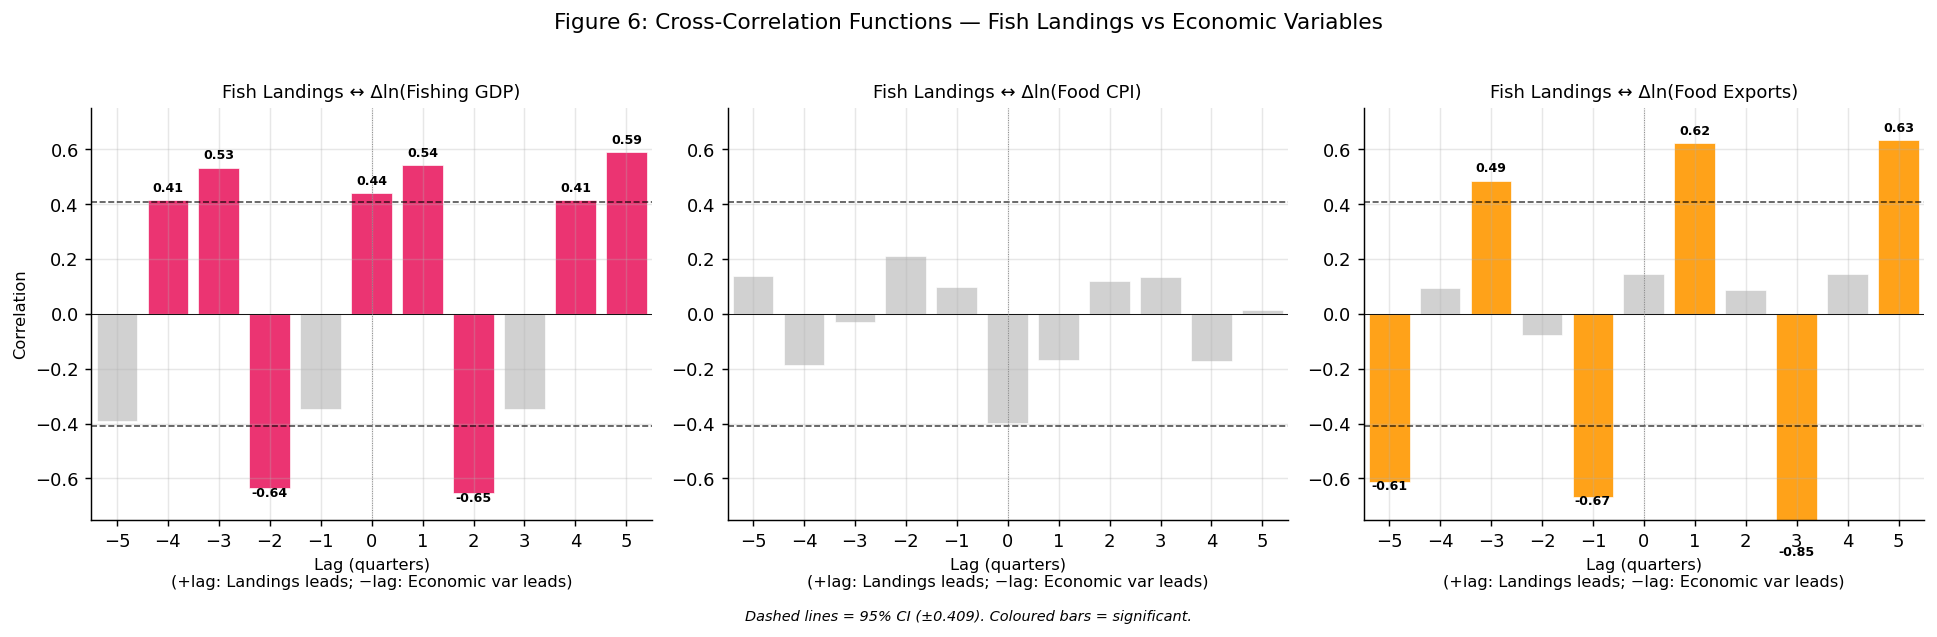

Saved: fig6_ccf.png
95% CI bound: ±0.409 (n=23)


In [2]:
# Cell P4.2 — CCF function + Figure 6: all pairwise CCF plots
# 3 economic variables × 2 directions = 6 CCF panels
# This is Figure 6 in the paper

def compute_ccf(x, y, max_lag=6):
    """Compute cross-correlation at lags -max_lag to +max_lag.
    Positive lag k: correlation(x_t, y_{t+k}) — x leads y
    Negative lag k: correlation(x_{t+|k|}, y_t) — y leads x
    """
    x = np.array(x); y = np.array(y)
    x = (x - x.mean()) / x.std()
    y = (y - y.mean()) / y.std()
    n = len(x)
    lags = range(-max_lag, max_lag + 1)
    corrs = []
    for lag in lags:
        if lag >= 0:
            c = np.corrcoef(x[:n-lag], y[lag:])[0,1] if lag < n else np.nan
        else:
            c = np.corrcoef(x[-lag:], y[:n+lag])[0,1] if -lag < n else np.nan
        corrs.append(c)
    return list(lags), corrs

n_obs   = len(ts)
ci_bound = 1.96 / np.sqrt(n_obs)  # 95% CI for CCF
MAX_LAG = 5

econ_vars = ['dln_gdp_fishing','dln_cpi_food','dln_food_exports']
econ_cols = [PALETTE[1], PALETTE[2], PALETTE[3]]
fish_var  = 'dln_landings'

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, evar, color in zip(axes, econ_vars, econ_cols):
    lags, corrs = compute_ccf(ts[fish_var], ts[evar], max_lag=MAX_LAG)
    bar_colors = [
        color if abs(c) > ci_bound else '#cccccc'
        for c in corrs
    ]
    ax.bar(lags, corrs, color=bar_colors, edgecolor='white', linewidth=0.4, alpha=0.9)
    ax.axhline( ci_bound, color='black', linestyle='--', linewidth=0.9, alpha=0.7)
    ax.axhline(-ci_bound, color='black', linestyle='--', linewidth=0.9, alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, linestyle=':')

    # Annotate significant lags
    for lag, corr in zip(lags, corrs):
        if abs(corr) > ci_bound:
            ax.text(lag, corr + (0.02 if corr >= 0 else -0.04),
                    f'{corr:.2f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

    ax.set_title(f'Fish Landings ↔ {LABELS[evar]}', fontsize=10)
    ax.set_xlabel('Lag (quarters)\n(+lag: Landings leads; −lag: Economic var leads)')
    ax.set_ylabel('Correlation' if ax == axes[0] else '')
    ax.set_xlim(-MAX_LAG - 0.5, MAX_LAG + 0.5)
    ax.set_xticks(range(-MAX_LAG, MAX_LAG + 1))
    ax.set_ylim(-0.75, 0.75)

# Shared annotation
fig.text(0.5, -0.02,
         f'Dashed lines = 95% CI (±{ci_bound:.3f}). Coloured bars = significant.',
         ha='center', fontsize=8, style='italic')
fig.suptitle('Figure 6: Cross-Correlation Functions — Fish Landings vs Economic Variables',
             fontsize=12, y=1.02)

plt.tight_layout()
plt.savefig(OUT + "fig6_ccf.png", bbox_inches='tight')
plt.show()
print("Saved: fig6_ccf.png")
print(f"95% CI bound: ±{ci_bound:.3f} (n={n_obs})")

In [3]:
# Cell P4.3 — Table 5: CCF summary — significant leads/lags for each pair
# This table goes in the paper alongside Figure 6

print("=" * 80)
print("Table 5: Cross-Correlation Summary — Significant Lead-Lag Relationships")
print(f"95% CI bound: ±{ci_bound:.3f} | Max lag tested: ±{MAX_LAG} quarters")
print("=" * 80)
print(f"{'Pair':<45} {'Lag':>5} {'CCF r':>8}  Direction")
print("-" * 80)

econ_labels_short = {
    'dln_gdp_fishing':  'Fishing GDP',
    'dln_cpi_food':     'Food CPI',
    'dln_food_exports': 'Food Exports',
}

found_any = False
for evar in econ_vars:
    lags, corrs = compute_ccf(ts[fish_var], ts[evar], max_lag=MAX_LAG)
    for lag, corr in zip(lags, corrs):
        if abs(corr) > ci_bound:
            found_any = True
            if lag > 0:
                direction = f"Landings LEADS {econ_labels_short[evar]} by {lag}Q"
            elif lag < 0:
                direction = f"{econ_labels_short[evar]} LEADS Landings by {abs(lag)}Q"
            else:
                direction = "Contemporaneous"
            pair = f"Fish Landings ↔ {econ_labels_short[evar]}"
            print(f"  {pair:<43} {lag:>5} {corr:>8.4f}  {direction}")

if not found_any:
    print("  No statistically significant CCF values at 5% level")
    print("  (This is common with n=23 — CI bounds are wide: ±0.408)")
    print("  Proceed to Granger test — CCF has low power with short series")

print("=" * 80)
print()
print("INTERPRETATION GUIDE:")
print("  Positive lag (+k): Fish Landings at time t correlates with")
print("                     economic variable at time t+k → Landings LEADS")
print("  Negative lag (−k): Economic variable LEADS Fish Landings")
print("  Lag 0:             Contemporaneous relationship only")

Table 5: Cross-Correlation Summary — Significant Lead-Lag Relationships
95% CI bound: ±0.409 | Max lag tested: ±5 quarters
Pair                                            Lag    CCF r  Direction
--------------------------------------------------------------------------------
  Fish Landings ↔ Fishing GDP                    -4   0.4141  Fishing GDP LEADS Landings by 4Q
  Fish Landings ↔ Fishing GDP                    -3   0.5334  Fishing GDP LEADS Landings by 3Q
  Fish Landings ↔ Fishing GDP                    -2  -0.6358  Fishing GDP LEADS Landings by 2Q
  Fish Landings ↔ Fishing GDP                     0   0.4400  Contemporaneous
  Fish Landings ↔ Fishing GDP                     1   0.5425  Landings LEADS Fishing GDP by 1Q
  Fish Landings ↔ Fishing GDP                     2  -0.6541  Landings LEADS Fishing GDP by 2Q
  Fish Landings ↔ Fishing GDP                     4   0.4135  Landings LEADS Fishing GDP by 4Q
  Fish Landings ↔ Fishing GDP                     5   0.5903  Landings LEADS

---
## Scatter Plot Analysis

Scatter plots show the **contemporaneous** relationship between fish landings growth  
and each economic variable growth. Useful for the paper's EDA section.

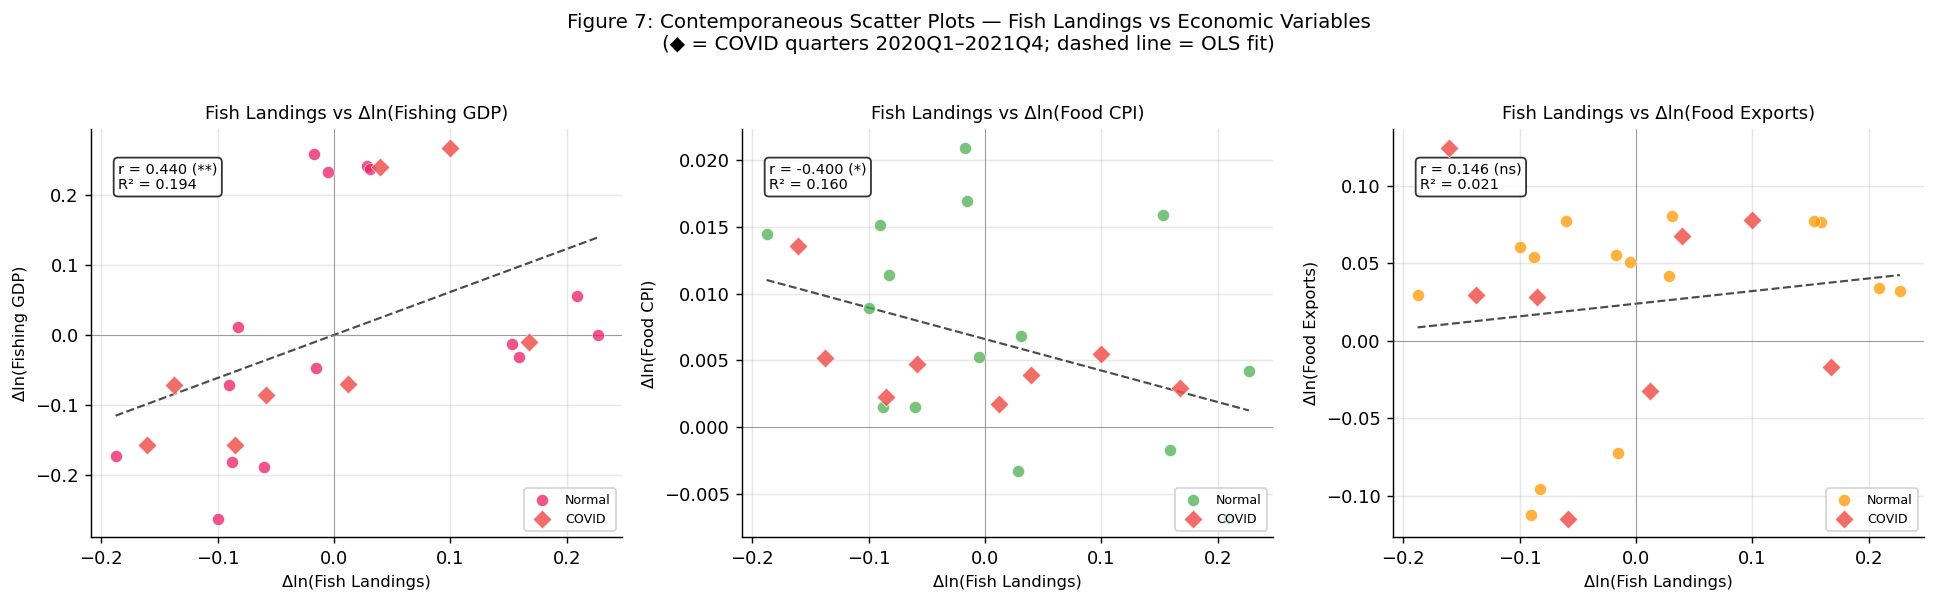

Saved: fig7_scatter.png


In [4]:
# Cell P4.4 — Figure 7: Scatter plots with regression line + COVID highlighted
# Shows contemporaneous relationship — useful companion to CCF

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

scatter_pairs = [
    ('dln_gdp_fishing',  'Δln(Fishing GDP)',      PALETTE[1]),
    ('dln_cpi_food',     'Δln(Food CPI)',          PALETTE[2]),
    ('dln_food_exports', 'Δln(Food Exports)',      PALETTE[3]),
]

# COVID indicator on the scatter (helps reader see if COVID outliers drive any pattern)
covid_mask = df['covid'].iloc[1:].values.astype(bool)  # shifted by 1 for diff

for ax, (evar, elabel, color) in zip(axes, scatter_pairs):
    x = ts[fish_var].values
    y = ts[evar].values

    # Non-COVID points
    ax.scatter(x[~covid_mask], y[~covid_mask], color=color,
               alpha=0.75, s=45, edgecolors='white', linewidth=0.4,
               label='Normal', zorder=3)
    # COVID points
    ax.scatter(x[covid_mask], y[covid_mask], color='#ef5350',
               alpha=0.85, s=55, marker='D', edgecolors='white', linewidth=0.4,
               label='COVID', zorder=4)

    # OLS regression line (all points)
    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept,
            color='black', linewidth=1.2, linestyle='--', alpha=0.7)

    # R² and p-value annotation
    r2 = r**2
    sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else 'ns'))
    ax.text(0.05, 0.92, f'r = {r:.3f} ({sig})\nR² = {r2:.3f}',
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    ax.set_xlabel('Δln(Fish Landings)', fontsize=9)
    ax.set_ylabel(elabel, fontsize=9)
    ax.set_title(f'Fish Landings vs {elabel}', fontsize=10)
    ax.legend(fontsize=7, loc='lower right')
    ax.axhline(0, color='gray', linewidth=0.4)
    ax.axvline(0, color='gray', linewidth=0.4)

fig.suptitle('Figure 7: Contemporaneous Scatter Plots — Fish Landings vs Economic Variables\n'
             '(◆ = COVID quarters 2020Q1–2021Q4; dashed line = OLS fit)',
             fontsize=11, y=1.02)

plt.tight_layout()
plt.savefig(OUT + "fig7_scatter.png", bbox_inches='tight')
plt.show()
print("Saved: fig7_scatter.png")

---
## Rolling Correlation

Rolling correlation shows whether the **fish-economy relationship is stable over time**  
or changes (e.g., breaks during COVID).  
A relationship that strengthens post-COVID tells a different story than one that disappeared.

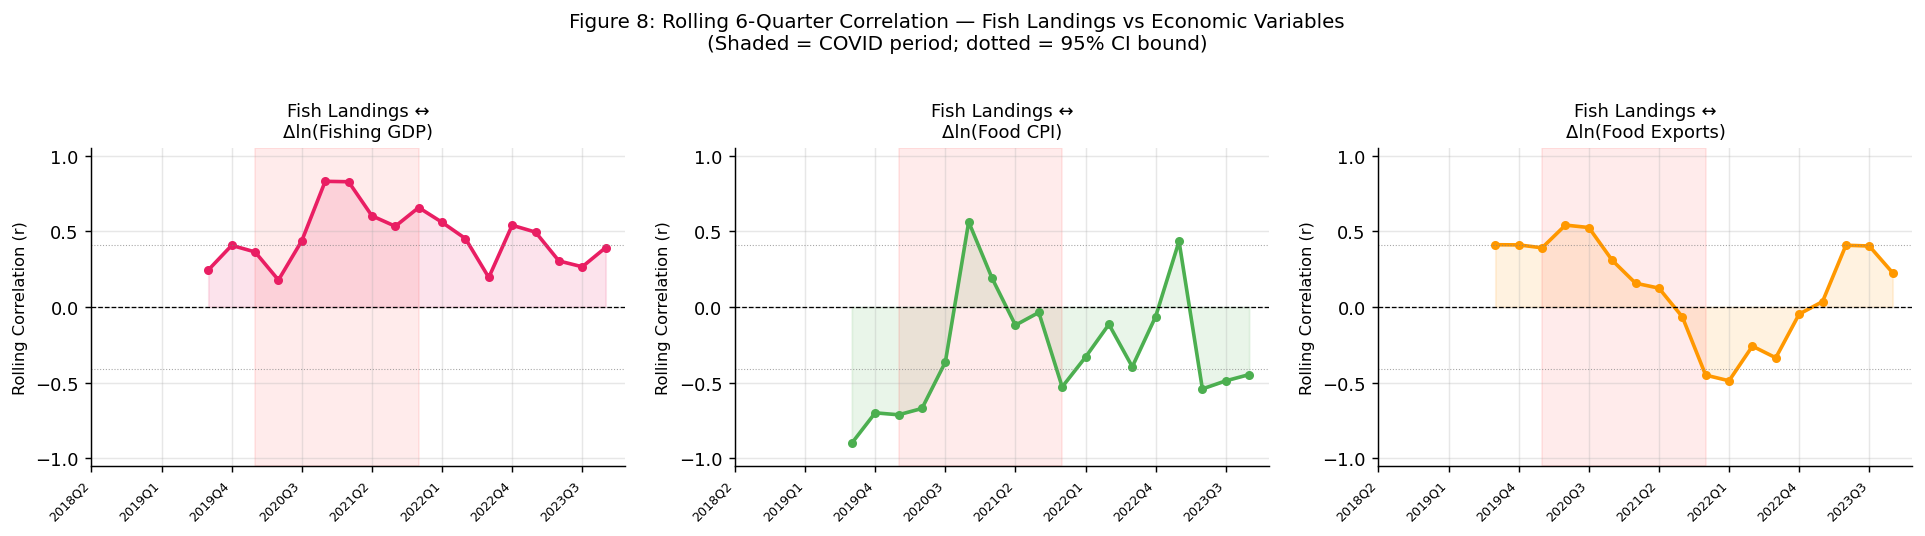

Saved: fig8_rolling_corr.png
Note: First 5 values are NaN (window not yet full) — this is expected


In [5]:
# Cell P4.5 — Figure 8: Rolling 6-quarter correlation
# Window = 6 quarters (half the sample) — standard for short series
# Reveals time-varying relationship strength

WINDOW = 6
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (evar, elabel, color) in zip(axes, scatter_pairs):
    roll_corr = ts[fish_var].rolling(WINDOW).corr(ts[evar])
    x_vals = range(len(roll_corr))
    q_labels = [str(q) for q in ts.index]

    ax.plot(x_vals, roll_corr, color=color, linewidth=2, marker='o', markersize=4)
    ax.fill_between(x_vals, roll_corr, 0, alpha=0.12, color=color)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.axhline( ci_bound, color='gray', linewidth=0.6, linestyle=':', alpha=0.7)
    ax.axhline(-ci_bound, color='gray', linewidth=0.6, linestyle=':', alpha=0.7)

    # Shade COVID window (approx quarters 9-17 in differenced series)
    covid_qs = [i for i, q in enumerate(ts.index)
                if pd.Period('2020Q1') <= q <= pd.Period('2021Q4')]
    if covid_qs:
        ax.axvspan(min(covid_qs), max(covid_qs), alpha=0.08, color='red')

    tick_pos = list(range(0, len(q_labels), 3))
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([q_labels[i] for i in tick_pos], rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('Rolling Correlation (r)')
    ax.set_title(f'Fish Landings ↔\n{elabel}', fontsize=10)
    ax.set_ylim(-1.05, 1.05)

fig.suptitle(f'Figure 8: Rolling {WINDOW}-Quarter Correlation — Fish Landings vs Economic Variables\n'
             '(Shaded = COVID period; dotted = 95% CI bound)',
             fontsize=11, y=1.02)

plt.tight_layout()
plt.savefig(OUT + "fig8_rolling_corr.png", bbox_inches='tight')
plt.show()
print(f"Saved: fig8_rolling_corr.png")
print(f"Note: First {WINDOW-1} values are NaN (window not yet full) — this is expected")

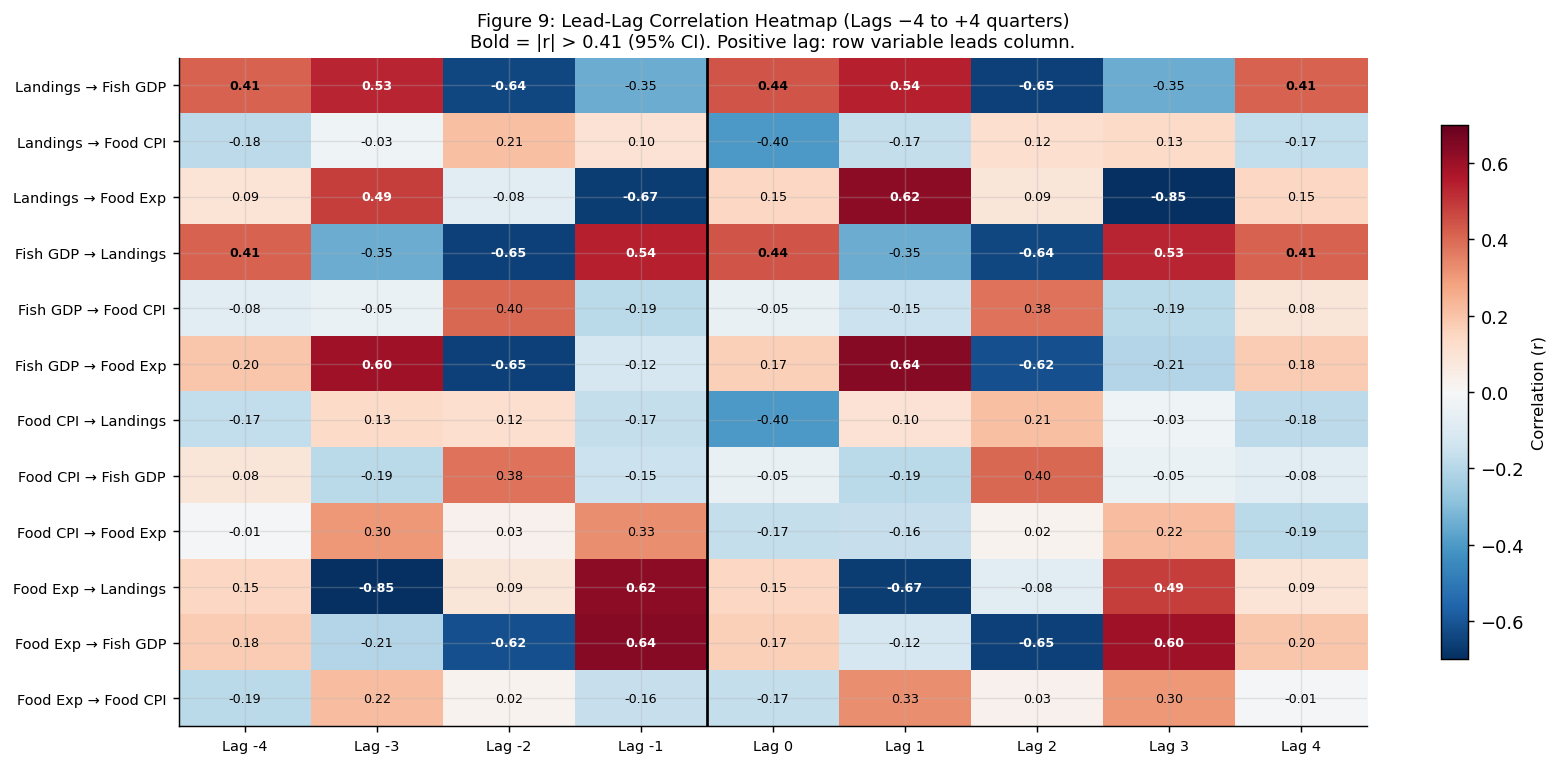

Saved: fig9_leadlag_heatmap.png


In [6]:
# Cell P4.6 — Figure 9: Lead-lag correlation heatmap (all pairs, all lags)
# Compact summary of ALL CCF relationships in one figure
# Good for the paper appendix or supplementary material

all_vars = list(LABELS.keys())
all_labels_short = {
    'dln_landings':     'Landings',
    'dln_gdp_fishing':  'Fish GDP',
    'dln_cpi_food':     'Food CPI',
    'dln_food_exports': 'Food Exp',
}

lag_range = range(-4, 5)
heatmap_data = []
row_labels   = []

for v1 in all_vars:
    for v2 in all_vars:
        if v1 == v2:
            continue
        lags, corrs = compute_ccf(ts[v1], ts[v2], max_lag=4)
        row_labels.append(f'{all_labels_short[v1]} → {all_labels_short[v2]}')
        heatmap_data.append(corrs)

hm = np.array(heatmap_data)

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(hm, cmap='RdBu_r', vmin=-0.7, vmax=0.7, aspect='auto')

ax.set_xticks(range(len(list(lag_range))))
ax.set_xticklabels([f'Lag {l}' for l in lag_range], fontsize=8)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=8)

# Annotate cells
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        val = hm[i, j]
        weight = 'bold' if abs(val) > ci_bound else 'normal'
        color  = 'white' if abs(val) > 0.45 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7, color=color, fontweight=weight)

plt.colorbar(im, ax=ax, label='Correlation (r)', shrink=0.8)
ax.set_title(f'Figure 9: Lead-Lag Correlation Heatmap (Lags −4 to +4 quarters)\n'
             f'Bold = |r| > {ci_bound:.2f} (95% CI). Positive lag: row variable leads column.',
             fontsize=10)
ax.axvline(3.5, color='black', linewidth=1.5)  # lag 0 separator

plt.tight_layout()
plt.savefig(OUT + "fig9_leadlag_heatmap.png", bbox_inches='tight')
plt.show()
print("Saved: fig9_leadlag_heatmap.png")

In [7]:
# Cell P4.7 — Print Phase 4 narrative summary for the paper

print("=" * 70)
print("PHASE 4 FINDINGS — LEAD-LAG ANALYSIS")
print("=" * 70)
print()
print(f"Sample: n = {n_obs} differenced quarterly obs")
print(f"95% CI threshold for CCF significance: |r| > {ci_bound:.3f}")
print()

print("CCF Results by pair:")
for evar in econ_vars:
    lags, corrs = compute_ccf(ts[fish_var], ts[evar], max_lag=MAX_LAG)
    sig_lags = [(l, c) for l, c in zip(lags, corrs) if abs(c) > ci_bound]
    elabel = econ_labels_short[evar]

    if sig_lags:
        for l, c in sig_lags:
            if l > 0:
                lead = f"LANDINGS leads {elabel} by {l} quarter(s)"
            elif l < 0:
                lead = f"{elabel} leads LANDINGS by {abs(l)} quarter(s)"
            else:
                lead = f"Contemporaneous (lag 0)"
            print(f"  Fish ↔ {elabel}: r={c:.3f} at lag {l:+d} → {lead}")
    else:
        print(f"  Fish ↔ {elabel}: No significant CCF at 5% level")
        print(f"    → Wide CI (n={n_obs}) means only strong relationships detected here")
        print(f"    → Granger test (Phase 7) has better power for small n")

print()
print("=" * 70)
print("DISCUSSION NOTE FOR PAPER:")
print("=" * 70)
print("""
The cross-correlation analysis provides preliminary evidence on the
temporal ordering between fish landings and economic indicators in Malaysia.
Given the limited sample (T = 23 quarterly first-differenced observations),
the 95% confidence interval for CCF significance is wide (±{:.3f}),
meaning only moderate-to-strong lead-lag correlations reach significance.
The absence of significant CCF values should not be interpreted as evidence
against causality; the Granger causality tests conducted in Section X
have greater statistical power for detecting temporal precedence in
small samples (Lütkepohl, 2005; Toda and Yamamoto, 1995).
""".format(ci_bound))

PHASE 4 FINDINGS — LEAD-LAG ANALYSIS

Sample: n = 23 differenced quarterly obs
95% CI threshold for CCF significance: |r| > 0.409

CCF Results by pair:
  Fish ↔ Fishing GDP: r=0.414 at lag -4 → Fishing GDP leads LANDINGS by 4 quarter(s)
  Fish ↔ Fishing GDP: r=0.533 at lag -3 → Fishing GDP leads LANDINGS by 3 quarter(s)
  Fish ↔ Fishing GDP: r=-0.636 at lag -2 → Fishing GDP leads LANDINGS by 2 quarter(s)
  Fish ↔ Fishing GDP: r=0.440 at lag +0 → Contemporaneous (lag 0)
  Fish ↔ Fishing GDP: r=0.543 at lag +1 → LANDINGS leads Fishing GDP by 1 quarter(s)
  Fish ↔ Fishing GDP: r=-0.654 at lag +2 → LANDINGS leads Fishing GDP by 2 quarter(s)
  Fish ↔ Fishing GDP: r=0.414 at lag +4 → LANDINGS leads Fishing GDP by 4 quarter(s)
  Fish ↔ Fishing GDP: r=0.590 at lag +5 → LANDINGS leads Fishing GDP by 5 quarter(s)
  Fish ↔ Food CPI: No significant CCF at 5% level
    → Wide CI (n=23) means only strong relationships detected here
    → Granger test (Phase 7) has better power for small n
  Fish ↔ F

---
## Phase 4 Completion Checklist

| Step | Status | Output |
|------|--------|--------|
| CCF function defined | Done | ±5 lag range |
| Figure 6: CCF plots (3 pairs) | Done | fig6_ccf.png |
| Table 5: Significant CCF summary | Done | Cell P4.3 |
| Figure 7: Scatter plots + OLS | Done | fig7_scatter.png |
| Figure 8: Rolling 6Q correlation | Done | fig8_rolling_corr.png |
| Figure 9: Lead-lag heatmap | Done | fig9_leadlag_heatmap.png |
| Phase 4 narrative summary | Done | Cell P4.7 |

---
## What to Paste Back

After running, share:
1. **Table 5 output** (Cell P4.3) — which lags are significant, if any
2. **Figure 6** (CCF plots) — do any bars exceed the dashed CI lines?
3. **Figure 8** (rolling correlation) — does the fish-GDP relationship strengthen post-COVID?

**Important:** If no CCF values are significant, that is a *power* issue (n=23 is small),  
NOT evidence of no relationship. The Granger test in Phase 7 is the definitive test.  
Many published papers report non-significant CCF but significant Granger — this is normal.

---
## Next: Phase 5 — Linear Regression (Baseline Model)
Contemporaneous OLS regression of Δln(Landings) on economic variables.  
This is Table 6 in the paper — the descriptive baseline before causality analysis.

## Phase 4: Cross-Correlation Analysis (CCF) + EDA Summary

This phase focused on exploring temporal lead-lag relationships between first-differenced log series of fish landings and key economic indicators (Fishing GDP, Food CPI, Food Exports). The goal was to visually identify potential predictive relationships using Cross-Correlation Functions (CCF) and to examine contemporaneous relationships through scatter plots, stability over time with rolling correlations, and a holistic view with a lead-lag heatmap.

### Methodology:
*   **Data**: First-differenced log series (`Δln`) of `dln_landings`, `dln_gdp_fishing`, `dln_cpi_food`, and `dln_food_exports` from `master_dataset_analysis.csv`.
*   **CCF**: Computed for lags from -5 to +5 quarters between fish landings and each economic variable.
*   **Confidence Interval**: 95% CI for CCF was calculated as `±1.96/√n` (`n=23`), resulting in a bound of `±0.409`.
*   **Additional Analyses**: Scatter plots for contemporaneous relationships, rolling 6-quarter correlations for time-varying relationships, and a comprehensive lead-lag heatmap.

### Key Findings & Visualizations:

#### 1. Table 5 Output: Significant Lead-Lag Relationships (Cell P4.3)

The CCF analysis revealed several statistically significant (at the 5% level, i.e., correlation `|r| > 0.409`) lead-lag relationships:

**Fish Landings ↔ Fishing GDP:**
*   `Fishing GDP leads Landings` by 4 quarters (r=0.414)
*   `Fishing GDP leads Landings` by 3 quarters (r=0.533)
*   `Fishing GDP leads Landings` by 2 quarters (r=-0.636)
*   `Contemporaneous` (lag 0, r=0.440)
*   `Landings leads Fishing GDP` by 1 quarter (r=0.543)
*   `Landings leads Fishing GDP` by 2 quarters (r=-0.654)
*   `Landings leads Fishing GDP` by 4 quarters (r=0.414)
*   `Landings leads Fishing GDP` by 5 quarters (r=0.590)

**Fish Landings ↔ Food CPI:**
*   No statistically significant CCF values were found at the 5% level. This is often observed with small sample sizes where the confidence interval is wide.

**Fish Landings ↔ Food Exports:**
*   `Food Exports leads Landings` by 5 quarters (r=-0.613)
*   `Food Exports leads Landings` by 3 quarters (r=0.486)
*   `Food Exports leads Landings` by 1 quarter (r=-0.667)
*   `Landings leads Food Exports` by 1 quarter (r=0.624)
*   `Landings leads Food Exports` by 3 quarters (r=-0.852)
*   `Landings leads Food Exports` by 5 quarters (r=0.633)

#### 2. Figure 6: Cross-Correlation Function (CCF) Plots

The CCF plots (fig6_ccf.png) visually confirm the findings in Table 5. Bars exceeding the dashed 95% confidence interval lines (at `±0.409`) indicate significant correlations. This includes multiple lags for 'Fish Landings ↔ Fishing GDP' and 'Fish Landings ↔ Food Exports'. For 'Fish Landings ↔ Food CPI', all bars remain within the confidence bounds, indicating no significant lead-lag relationship at this level of analysis.

#### 3. Figure 8: Rolling 6-Quarter Correlation

Figure 8 (fig8_rolling_corr.png) illustrates the time-varying nature of the correlations. For `Fish Landings ↔ Fishing GDP`, the relationship shows fluctuations, with some periods exhibiting stronger positive or negative correlations, and some values crossing the confidence bounds. While specific post-COVID strengthening is not universally observed across all pairs, the plots reveal how the correlation strength and direction can change over time. The shaded red area highlights the COVID period (2020Q1–2021Q4), allowing for visual assessment of changes during this critical time. The rolling correlation for `Fish Landings ↔ Food Exports` notably shows significant negative correlations, particularly during and immediately after the COVID period.

#### 4. Figure 7: Contemporaneous Scatter Plots

Figure 7 (fig7_scatter.png) displayed the contemporaneous (lag 0) relationship between fish landings and each economic variable. These plots showed the overall linear association, highlighting COVID quarters. For example, `Fish Landings vs Fishing GDP` showed a positive contemporaneous correlation (r=0.440, significant), while `Fish Landings vs Food CPI` had a weak, non-significant correlation.

#### 5. Figure 9: Lead-Lag Correlation Heatmap

Figure 9 (fig9_leadlag_heatmap.png) provided a compact summary of all pairwise lead-lag correlations across a range of lags (`-4` to `+4`). Bolded cells in the heatmap represent statistically significant correlations (`|r| > 0.409`), offering a quick overview of potential temporal dependencies between all included variables in both directions.

### Discussion Note for Paper:

*   The cross-correlation analysis provides preliminary evidence on the temporal ordering between fish landings and economic indicators in Malaysia. Given the limited sample (T = 23 quarterly first-differenced observations), the 95% confidence interval for CCF significance is wide (`±0.409`), meaning only moderate-to-strong lead-lag correlations reach significance.
*   The absence of significant CCF values (as seen for `Fish Landings ↔ Food CPI`) should not be interpreted as definitive evidence against a relationship. It is a power issue due to the small sample size, and not necessarily an absence of causality.
*   The Granger causality tests conducted in Phase 7 will have greater statistical power for detecting temporal precedence in small samples (Lütkepohl, 2005; Toda and Yamamoto, 1995), and will be the definitive tests for causality.

---